In [2]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# estilo de gráficas
sns.set_style("whitegrid")

In [3]:
# ==========================================
# CARGAR DATOS
# ==========================================

df_final = pd.read_csv("../../Datos/saber11_limpio_base.csv")

df_final.head()

,periodo,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_codigo_icfes,cole_depto_ubicacion,...,punt_global,anio,fami_personashogar_num,fami_cuartoshogar_num,fami_estratovivienda_num,estu_fechanacimiento_dt,edad,densidad_hogar,indice_tecnologico,indice_bienes_hogar
0,20194,sb11201940125751,urbano,no,a,academico,411769000127,411769000127,702142,bogota,...,310.0,2019,3.5,2,2,2002-11-14,16.1,1.750000,2,4
1,20194,sb11201940049452,urbano,no,a,academico,111279000168,111279000168,73031,bogota,...,217.0,2019,3.5,3,2,2000-02-13,18.9,1.166667,0,1
2,20194,sb11201940292128,urbano,no,a,academico,111279000966,111279000966,25163,bogota,...,261.0,2019,5.5,2,3,2001-10-16,17.2,2.750000,2,3
3,20194,sb11201940062240,urbano,no,a,academico,111001020095,111001020095,113043,bogota,...,289.0,2019,7.5,6,2,2002-05-20,16.6,1.250000,2,3
4,20194,sb11201940135822,urbano,no,a,tecnico/academico,111001013129,111001013129,90787,bogota,...,267.0,2019,1.5,1,3,2003-04-29,15.7,1.500000,2,2


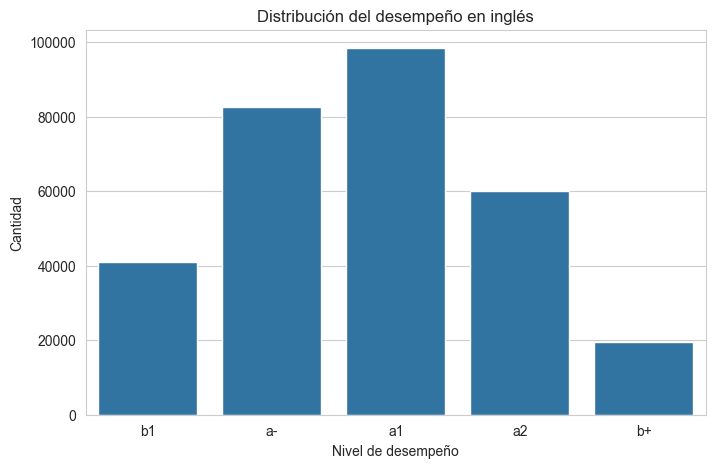

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x="desemp_ingles"
)

plt.title("Distribución del desempeño en inglés")
plt.xlabel("Nivel de desempeño")
plt.ylabel("Cantidad")

plt.show()

### Insight 1: Distribución del desempeño en inglés

Se observa que la variable objetivo presenta un desbalance moderado entre categorías. Los niveles A1 y A- concentran la mayor cantidad de estudiantes, mientras que B+ representa la menor proporción de observaciones.

Esto indica que el modelo tendrá mayor facilidad para aprender patrones asociados a categorías frecuentes y más dificultad para identificar correctamente niveles menos representados, como B+.

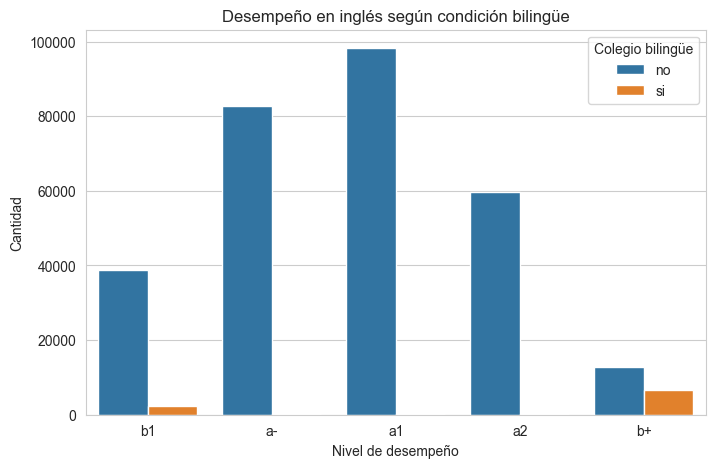

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_final,
    x="desemp_ingles",
    hue="cole_bilingue"
)

plt.title("Desempeño en inglés según condición bilingüe")
plt.xlabel("Nivel de desempeño")
plt.ylabel("Cantidad")
plt.legend(title="Colegio bilingüe")

plt.show()

In [6]:
# tabla de proporciones
tabla_bilingue = pd.crosstab(
    df_final["cole_bilingue"],
    df_final["desemp_ingles"],
    normalize="index"
) * 100

tabla_bilingue

desemp_ingles,a-,a1,a2,b+,b1
cole_bilingue,,,,,
no,28.289798,33.645865,20.451744,4.377038,13.235556
si,0.732034,1.928034,3.361171,69.027735,24.951026


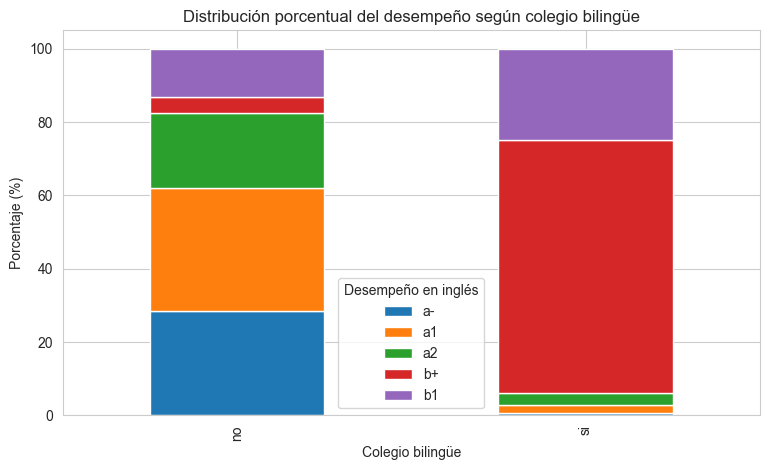

In [7]:
tabla_bilingue.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)

plt.title("Distribución porcentual del desempeño según colegio bilingüe")
plt.xlabel("Colegio bilingüe")
plt.ylabel("Porcentaje (%)")

plt.legend(title="Desempeño en inglés")
plt.show()

### Insight 2: Impacto de la condición bilingüe

Se observa una diferencia importante en la distribución del desempeño en inglés según si el establecimiento educativo es bilingüe o no.

Los colegios no bilingües concentran una mayor proporción de estudiantes en niveles básicos e intermedios (A1 y A-), mientras que los colegios bilingües presentan una participación considerablemente más alta en niveles avanzados de desempeño (B+ y B1).

Este hallazgo sugiere que la condición bilingüe del establecimiento es un factor institucional relevante asociado al desempeño en inglés, resultado que además es consistente con las variables más influyentes identificadas por el modelo Random Forest.

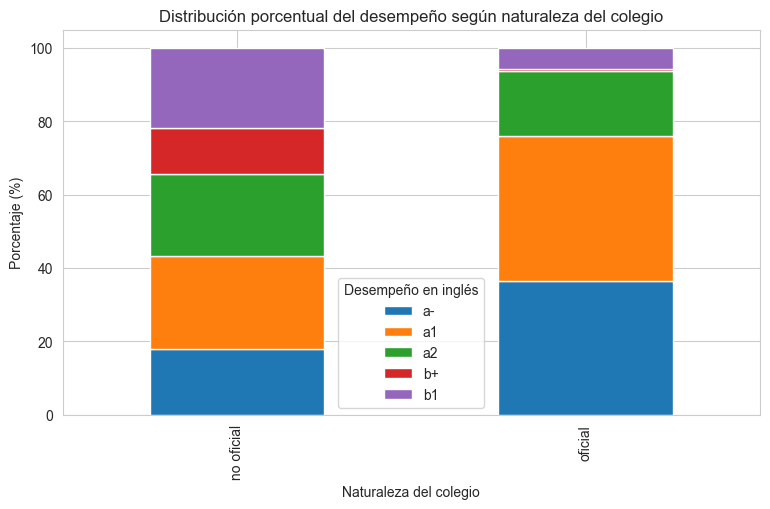

In [8]:
tabla_naturaleza = pd.crosstab(
    df_final["cole_naturaleza"],
    df_final["desemp_ingles"],
    normalize="index"
) * 100

tabla_naturaleza.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5)
)

plt.title("Distribución porcentual del desempeño según naturaleza del colegio")
plt.xlabel("Naturaleza del colegio")
plt.ylabel("Porcentaje (%)")

plt.legend(title="Desempeño en inglés")
plt.show()

### Insight 3: Impacto de la naturaleza del colegio

La naturaleza del establecimiento educativo parece estar asociada al desempeño en inglés de los estudiantes.

Los colegios no oficiales presentan una mayor proporción de estudiantes en niveles más altos de desempeño (B1 y B+), mientras que en los colegios oficiales se concentra una mayor participación de estudiantes en niveles básicos e intermedios (A- y A1).

Este resultado sugiere que la naturaleza del establecimiento educativo puede influir en las oportunidades de aprendizaje del inglés, convirtiéndose en una característica relevante para anticipar el nivel de desempeño estudiantil. Además, esta variable fue identificada como una de las más importantes por el modelo Random Forest.

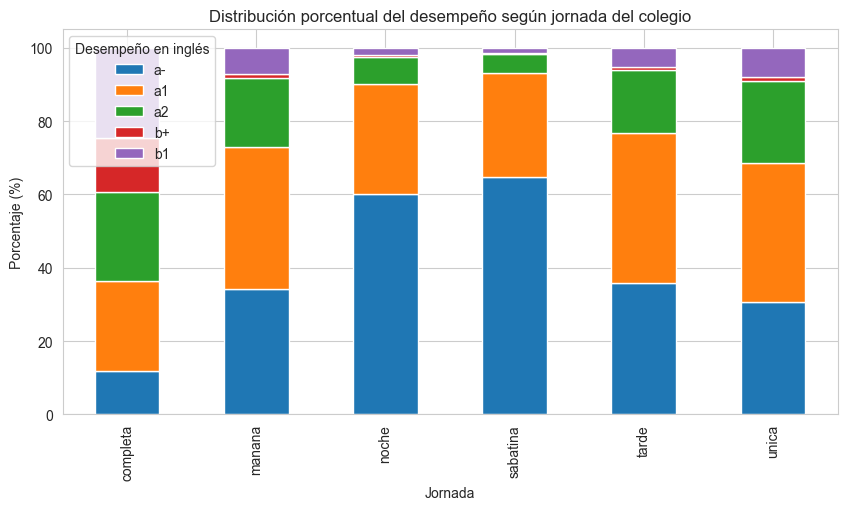

In [9]:
tabla_jornada = pd.crosstab(
    df_final["cole_jornada"],
    df_final["desemp_ingles"],
    normalize="index"
) * 100

tabla_jornada.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Distribución porcentual del desempeño según jornada del colegio")
plt.xlabel("Jornada")
plt.ylabel("Porcentaje (%)")

plt.legend(title="Desempeño en inglés")
plt.show()

### Insight 4: Impacto de la jornada del colegio

La jornada del establecimiento educativo parece estar relacionada con el desempeño en inglés de los estudiantes.

Se observa que los estudiantes de colegios con jornada completa presentan una mayor proporción de desempeños altos (B1 y B+), mientras que otras jornadas, como noche y sabatina, muestran una concentración mayor en niveles bajos (A- y A1).

Este hallazgo es consistente con los resultados del modelo Random Forest, donde las variables asociadas a la jornada escolar fueron identificadas como las más importantes para anticipar el nivel de desempeño en inglés. Esto sugiere que la intensidad horaria y el tiempo de exposición académica podrían influir en el aprendizaje del idioma.